In [1]:
import pandas as pd

In [2]:
file_path = '../data/processed/latest_ml_dataset_v4_finbert.parquet'
df = pd.read_parquet(file_path)
df.head()

,timestamp,symbol,open,high,low,close,volume,RSI,MACD,MACD_signal,SMA_20,EMA_20,BB_high,BB_low,ticker_sentiment,news_count,market_sentiment,reddit_hype,label
0,2026-02-13 14:30:00+00:00,AAPL,262.010010,262.230011,258.799988,259.299988,4578357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1
1,2026-02-13 14:35:00+00:00,AAPL,259.339996,260.260010,258.799988,259.385010,772714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1
2,2026-02-13 14:40:00+00:00,AAPL,259.350006,260.190002,259.019989,259.519989,646951,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1
3,2026-02-13 14:45:00+00:00,AAPL,259.510010,260.980011,259.399994,260.274994,611692,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0
4,2026-02-13 14:50:00+00:00,AAPL,260.269989,260.326691,258.820007,259.500000,564613,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14037 entries, 0 to 14036
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   timestamp         14037 non-null  datetime64[ns, UTC]
 1   symbol            14037 non-null  str                
 2   open              14037 non-null  float64            
 3   high              14037 non-null  float64            
 4   low               14037 non-null  float64            
 5   close             14037 non-null  float64            
 6   volume            14037 non-null  int64              
 7   RSI               13998 non-null  float64            
 8   MACD              13962 non-null  float64            
 9   MACD_signal       13938 non-null  float64            
 10  SMA_20            13980 non-null  float64            
 11  EMA_20            13980 non-null  float64            
 12  BB_high           13980 non-null  float64            
 13  BB_low      

In [4]:
print(df.isnull().sum())

timestamp            0
symbol               0
open                 0
high                 0
low                  0
close                0
volume               0
RSI                 39
MACD                75
MACD_signal         99
SMA_20              57
EMA_20              57
BB_high             57
BB_low              57
ticker_sentiment     0
news_count           0
market_sentiment     0
reddit_hype          0
label                0
dtype: int64


## Exploratory Data Analysis

The cells below summarize the dataset, check for missing values and duplicates, and visualize the numeric columns and any likely target column if present.

In [8]:
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [9]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(list(df.columns))

print("\nData types:")
display(df.dtypes.to_frame(name="dtype"))

print("\nNumeric summary:")
display(df.describe().T)

print("\nFull summary including categorical columns:")
display(df.describe(include="all").T)

Dataset shape: (14037, 19)

Column names:
['timestamp', 'symbol', 'open', 'high', 'low', 'close', 'volume', 'RSI', 'MACD', 'MACD_signal', 'SMA_20', 'EMA_20', 'BB_high', 'BB_low', 'ticker_sentiment', 'news_count', 'market_sentiment', 'reddit_hype', 'label']

Data types:


,dtype
timestamp,"datetime64[ns, UTC]"
symbol,str
open,float64
high,float64
low,float64
close,float64
volume,int64
RSI,float64
MACD,float64
MACD_signal,float64



Numeric summary:


,count,mean,std,min,25%,50%,75%,max
open,14037.0,324.562520,55.719987,245.509995,270.609985,308.541687,382.489990,4.479900e+02
high,14037.0,324.987535,55.871132,245.949997,270.915009,308.859985,383.100006,4.491600e+02
low,14037.0,324.137906,55.566657,245.509995,270.399994,308.172699,381.850006,4.475200e+02
close,14037.0,324.572444,55.727084,245.529999,270.619995,308.540009,382.529999,4.479800e+02
volume,14037.0,516167.136995,811818.890453,0.000000,185348.000000,314033.000000,547387.000000,1.334054e+07
RSI,13998.0,50.690385,12.762430,9.496902,42.129704,50.480869,59.102488,9.248364e+01
MACD,13962.0,0.073663,0.939334,-4.879538,-0.351215,0.023065,0.398413,5.824878e+00
MACD_signal,13938.0,0.073305,0.886674,-4.215068,-0.340932,0.018402,0.384468,5.171851e+00
SMA_20,13980.0,324.462858,55.620732,246.303259,270.572317,308.467349,382.334166,4.460136e+02
EMA_20,13980.0,324.463020,55.611195,246.249810,270.501841,308.434034,382.377315,4.454124e+02



Full summary including categorical columns:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
timestamp,14037,NaN,NaN,NaN,2026-03-29 18:44:15.246847232+00:00,2026-02-13 14:30:00+00:00,2026-03-06 20:55:00+00:00,2026-03-27 19:55:00+00:00,2026-04-20 19:55:00+00:00,2026-05-11 19:50:00+00:00,NaN
symbol,14037,3,AAPL,4679,NaN,NaN,NaN,NaN,NaN,NaN,NaN
open,14037.0,NaN,NaN,NaN,324.56252,245.509995,270.609985,308.541687,382.48999,447.98999,55.719987
high,14037.0,NaN,NaN,NaN,324.987535,245.949997,270.915009,308.859985,383.100006,449.160004,55.871132
low,14037.0,NaN,NaN,NaN,324.137906,245.509995,270.399994,308.172699,381.850006,447.519989,55.566657
close,14037.0,NaN,NaN,NaN,324.572444,245.529999,270.619995,308.540009,382.529999,447.980011,55.727084
volume,14037.0,NaN,NaN,NaN,516167.136995,0.0,185348.0,314033.0,547387.0,13340539.0,811818.890453
RSI,13998.0,NaN,NaN,NaN,50.690385,9.496902,42.129704,50.480869,59.102488,92.483644,12.76243
MACD,13962.0,NaN,NaN,NaN,0.073663,-4.879538,-0.351215,0.023065,0.398413,5.824878,0.939334
MACD_signal,13938.0,NaN,NaN,NaN,0.073305,-4.215068,-0.340932,0.018402,0.384468,5.171851,0.886674



Missing values:


,missing_count,missing_pct
MACD_signal,99,0.705279
MACD,75,0.534302
SMA_20,57,0.406070
BB_high,57,0.406070
BB_low,57,0.406070
EMA_20,57,0.406070
RSI,39,0.277837


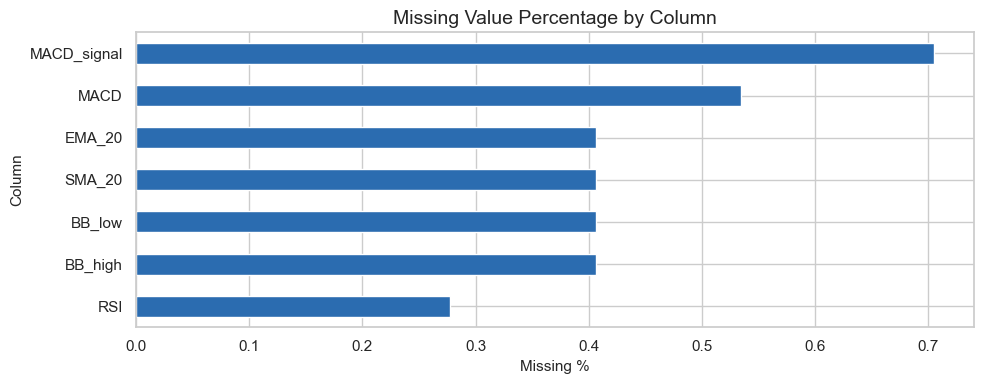


Duplicate rows: 0


In [10]:
categorical_cols = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

print("\nMissing values:")
missing_values = df.isnull().sum().to_frame(name="missing_count")
missing_values["missing_pct"] = (missing_values["missing_count"] / len(df)) * 100
missing_values = missing_values.sort_values("missing_count", ascending=False)
missing_nonzero = missing_values[missing_values["missing_count"] > 0]
display(missing_nonzero)

if not missing_nonzero.empty:
    ax = missing_nonzero.sort_values("missing_pct", ascending=True).plot(
        kind="barh",
        y="missing_pct",
        legend=False,
        color="#2b6cb0",
        figsize=(10, max(4, 0.35 * len(missing_nonzero))),
        title="Missing Value Percentage by Column",
    )
    ax.set_xlabel("Missing %")
    ax.set_ylabel("Column")
    plt.tight_layout()
    plt.show()

print("\nDuplicate rows:", df.duplicated().sum())


Categorical columns: ['symbol']


,unique_values,missing_count
symbol,3,0



Top values for symbol:


,count
symbol,
AAPL,4679
GOOGL,4679
TSLA,4679


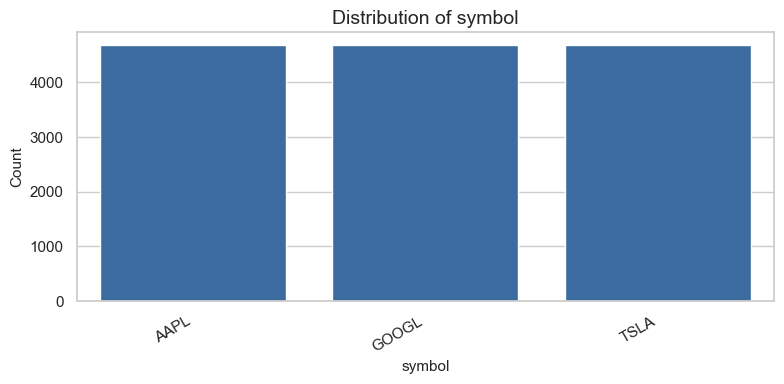

In [11]:
print("\nCategorical columns:", categorical_cols)
if categorical_cols:
    cat_summary = pd.DataFrame({
        "unique_values": df[categorical_cols].nunique(),
        "missing_count": df[categorical_cols].isnull().sum(),
    }).sort_values("unique_values", ascending=False)
    display(cat_summary)

    for col in categorical_cols:
        print(f"\nTop values for {col}:")
        top_values = df[col].value_counts(dropna=False).head(10)
        display(top_values.to_frame(name="count"))

        fig, ax = plt.subplots(figsize=(8, 4))
        sns.countplot(data=df, x=col, order=top_values.index, ax=ax, color="#2b6cb0")
        ax.set_title(f"Distribution of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()


Numeric columns: ['open', 'high', 'low', 'close', 'volume', 'RSI', 'MACD', 'MACD_signal', 'SMA_20', 'EMA_20', 'BB_high', 'BB_low', 'ticker_sentiment', 'news_count', 'market_sentiment', 'reddit_hype', 'label']

Correlation matrix:


,open,high,low,close,volume,RSI,MACD,MACD_signal,SMA_20,EMA_20,BB_high,BB_low,ticker_sentiment,news_count,market_sentiment,reddit_hype,label
open,1.000000,0.999963,0.999963,0.999931,0.159718,0.036258,0.079298,0.083519,0.999388,0.999564,0.999058,0.998509,0.035379,0.149890,-0.045038,0.097606,-0.003011
high,0.999963,1.000000,0.999939,0.999966,0.161855,0.038235,0.079916,0.083729,0.999336,0.999519,0.999081,0.998379,0.035065,0.149987,-0.044948,0.097461,-0.002918
low,0.999963,0.999939,1.000000,0.999962,0.157609,0.037949,0.079488,0.083526,0.999364,0.999542,0.998963,0.998558,0.035641,0.149975,-0.045114,0.097742,-0.003141
close,0.999931,0.999966,0.999962,1.000000,0.159854,0.039630,0.079964,0.083634,0.999326,0.999510,0.999004,0.998438,0.035331,0.150126,-0.044963,0.097574,-0.002998
volume,0.159718,0.161855,0.157609,0.159854,1.000000,0.010303,0.020534,0.008291,0.158579,0.158859,0.164542,0.152252,-0.023491,0.001084,0.000969,-0.007223,0.009856
RSI,0.036258,0.038235,0.037949,0.039630,0.010303,1.000000,0.763352,0.645653,0.009700,0.013083,0.013725,0.005548,-0.015041,0.038272,0.016050,-0.016252,-0.007434
MACD,0.079298,0.079916,0.079488,0.079964,0.020534,0.763352,1.000000,0.955330,0.052707,0.055314,0.059347,0.045811,0.006692,0.091904,-0.011141,0.035930,-0.005366
MACD_signal,0.083519,0.083729,0.083526,0.083634,0.008291,0.645653,0.955330,1.000000,0.064239,0.064667,0.069429,0.058821,0.025191,0.095090,-0.018201,0.051333,-0.008317
SMA_20,0.999388,0.999336,0.999364,0.999326,0.158579,0.009700,0.052707,0.064239,1.000000,0.999965,0.999416,0.999382,0.036815,0.148529,-0.045399,0.098272,-0.003490
EMA_20,0.999564,0.999519,0.999542,0.999510,0.158859,0.013083,0.055314,0.064667,0.999965,1.000000,0.999432,0.999295,0.036367,0.148606,-0.045218,0.097896,-0.003361



Strongest absolute correlations (excluding self-correlation):


,,abs_correlation
close,high,0.999966
high,close,0.999966
EMA_20,SMA_20,0.999965
SMA_20,EMA_20,0.999965
open,low,0.999963
low,open,0.999963
high,open,0.999963
open,high,0.999963
close,low,0.999962
low,close,0.999962


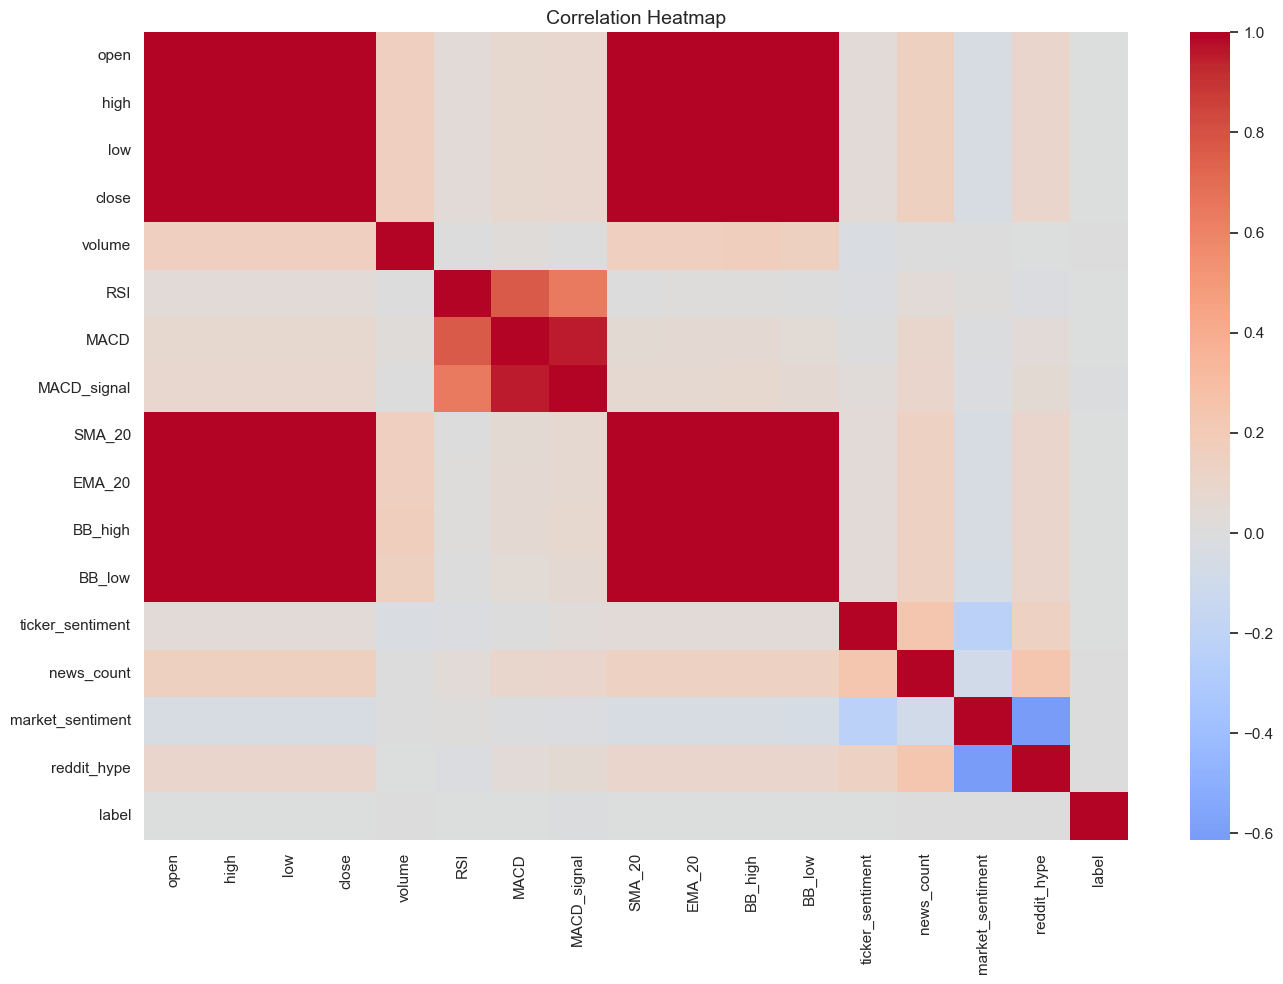

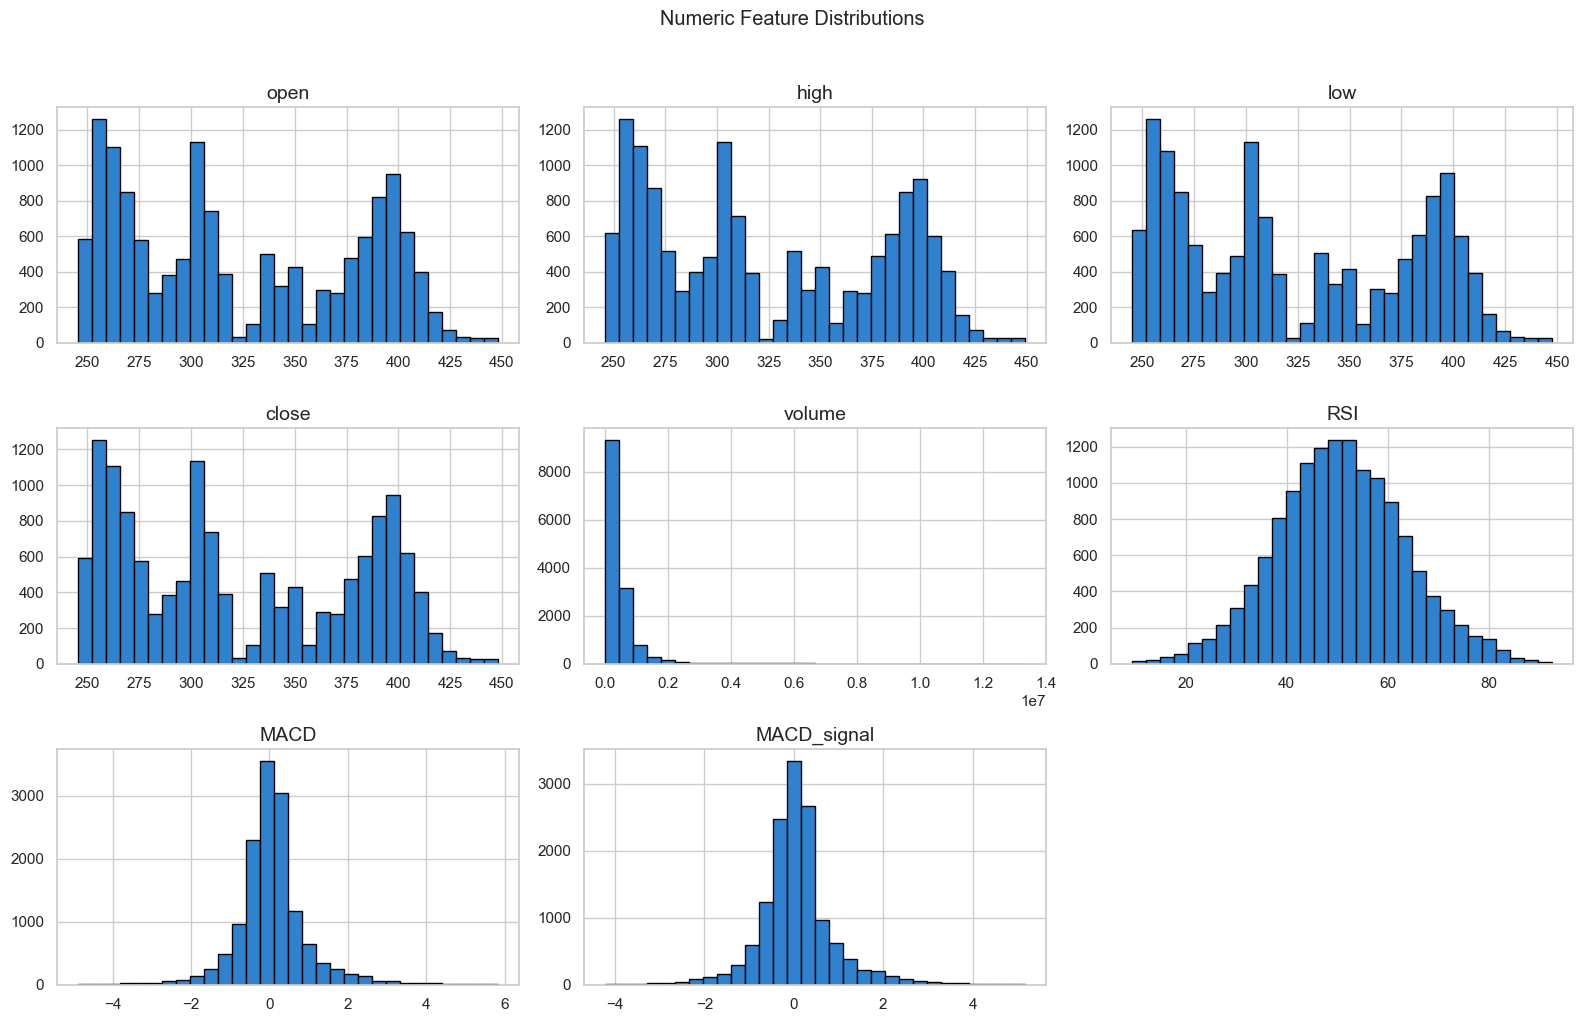

In [12]:
print("\nNumeric columns:", numeric_cols)
if numeric_cols:
    corr = df[numeric_cols].corr(numeric_only=True)

    print("\nCorrelation matrix:")
    display(corr)

    if len(numeric_cols) > 1:
        corr_pairs = (
            corr.abs()
            .where(~np.eye(len(corr), dtype=bool))
            .stack()
            .sort_values(ascending=False)
            .head(10)
        )
        print("\nStrongest absolute correlations (excluding self-correlation):")
        display(corr_pairs.to_frame(name="abs_correlation"))

        fig, ax = plt.subplots(figsize=(14, 10))
        sns.heatmap(corr, cmap="coolwarm", center=0, square=False, ax=ax)
        ax.set_title("Correlation Heatmap")
        plt.tight_layout()
        plt.show()

    plot_cols = [col for col in numeric_cols if col != "label"][:8]
    if plot_cols:
        df[plot_cols].hist(bins=30, figsize=(16, 10), color="#3182ce", edgecolor="black")
        plt.suptitle("Numeric Feature Distributions", y=1.02)
        plt.tight_layout()
        plt.show()


Target column detected: label


,count
label,
0,7019
1,7018


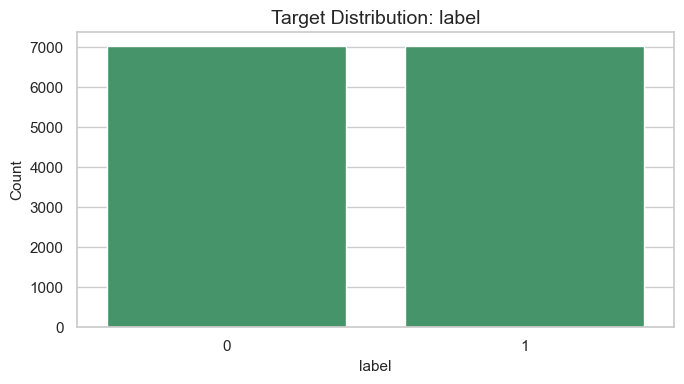

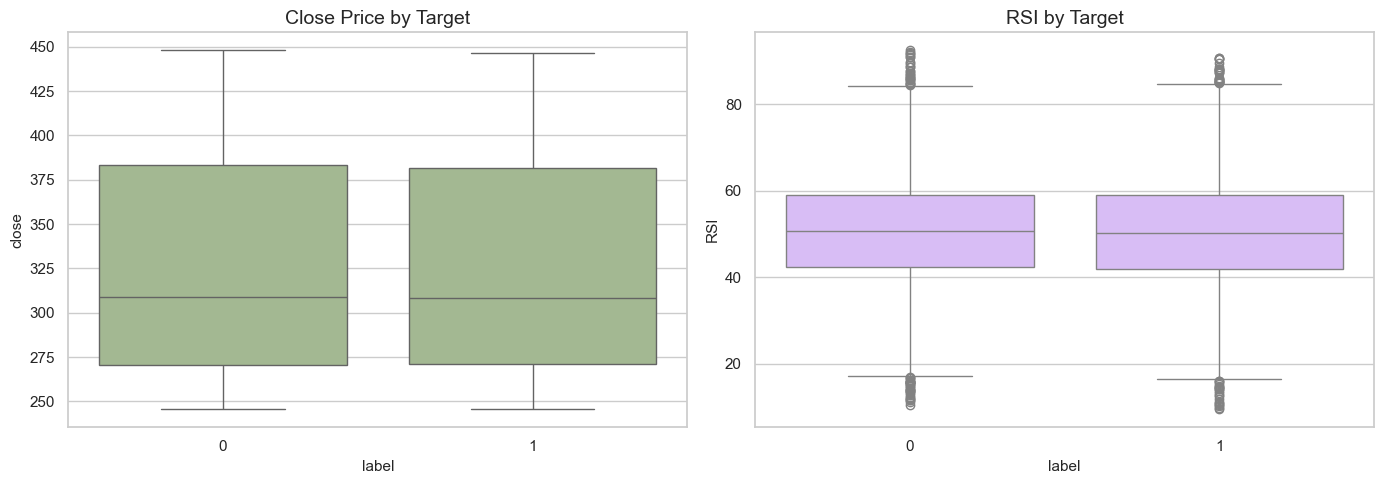

In [13]:
candidate_target_cols = ["target", "label", "movement", "direction", "signal", "class", "y"]
target_col = next((col for col in candidate_target_cols if col in df.columns), None)

if target_col:
    print(f"\nTarget column detected: {target_col}")
    target_counts = df[target_col].value_counts(dropna=False)
    display(target_counts.to_frame(name="count"))

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.countplot(x=df[target_col], ax=ax, color="#38a169")
    ax.set_title(f"Target Distribution: {target_col}")
    ax.set_xlabel(target_col)
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

    if "symbol" in df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        sns.boxplot(data=df, x=target_col, y="close", ax=axes[0], color="#a3be8c")
        axes[0].set_title("Close Price by Target")
        sns.boxplot(data=df, x=target_col, y="RSI", ax=axes[1], color="#d8b4fe")
        axes[1].set_title("RSI by Target")
        plt.tight_layout()
        plt.show()
else:
    print("\nNo obvious target column found in the dataset.")